## Preamble

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

from cpymad.madx import Madx

# Comment out the following lines if plotting cells give an error
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from plot_settings import setPlotSettings
setPlotSettings(font=True)

## Case 1 -- sans command block A

### cell_full:

In [3]:
madx = Madx(stdout=False)
madx.input(f'''
    BEAM, particle=proton, energy=275.0;
    // Geometry
    L_drift  =  1.5;
    L_dipole = 12.0;
    L_quad   =  1.0;
    theta    =  0.036;
    
    L_half_arc_cell  = L_quad +       L_dipole + 2*L_drift;    // Regular arc half cell
    L_half_comp_cell = L_quad + (2/3)*L_dipole + 2*L_drift;    // Compact dispersion suppressor half cell
    
    // Strengths
    kd = 0.084;
    kf = 0.086;
    kdds = kd;
    kfds = kf;
    
    // Drifts
    D:        DRIFT, L =       L_drift;
    D_quart:  DRIFT, L = (1/4)*L_dipole;      // Quarter of the length of a dipole
    DIP_zero: DRIFT, L =       L_dipole;      // A full length, zero angle dipole, aka drift !!
    
    // Dipoles
    DIP_full: SBEND, L =       L_dipole, ANGLE =       theta;  // Nominal arc dipole
    DIP_half: SBEND, L = (1/2)*L_dipole, ANGLE = (1/2)*theta;  // Half length, half angle, full field
    DIP_weak: SBEND, L =       L_dipole, ANGLE = (1/2)*theta;  // Full length, half angle, half field
    DIP_comp:   SBEND, L = (2/3)*L_dipole, ANGLE = (2/3)*theta;  // 2/3  length, 2/3  angle, full field 
    
    // Quadrupoles
    QFH:   QUADRUPOLE, L= 0.5*L_quad, K1 :=  kf;    // Half an arc quad, F
    QDH:   QUADRUPOLE, L= 0.5*L_quad, K1 := -kd;    // Half an arc quad, D
    QFHds: QUADRUPOLE, L= 0.5*L_quad, K1 :=  kfds;  // Half a dispersion suppressor quad, F
    QDHds: QUADRUPOLE, L= 0.5*L_quad, K1 := -kdds;  // Half a dispersion suppressor quad, D
    
    // Beamlines
    interior_full: LINE=(D,          DIP_full,          D); // Interior with a full strength dipole
    interior_half: LINE=(D, D_quart, DIP_half, D_quart, D); // Interior with a half strength dipole
    interior_weak: LINE=(D,          DIP_weak,          D); // Alternate half strength interior
    interior_zero: LINE=(D,          DIP_zero,          D); // Interior with zero bend dipole
    interior_comp: LINE=(D,          DIP_comp,          D); // Compact interior
    
    cell_full: LINE=(QFH,   interior_full,   QDH,QDH,   interior_full, QFH);  // See figure
    cell_half: LINE=(QFH,   interior_half,   QDH,QDH,   interior_half, QFH);
    cell_weak: LINE=(QFH,   interior_weak,   QDH,QDH,   interior_half, QFH);
    cell_zero: LINE=(QFH,   interior_zero,   QDH,QDH,   interior_zero, QFH);
    cell_comp: LINE=(QFHds, interior_comp, QDHds,QDHds, interior_comp, QFHds);
    
    ds_none: LINE=(5*cell_full,              4*cell_zero,              5*cell_full);
    ds_half: LINE=(3*cell_full, 2*cell_half, 4*cell_zero, 2*cell_half, 3*cell_full);
    ds_weak: LINE=(3*cell_full, 2*cell_weak, 4*cell_zero, 2*cell_weak, 3*cell_full);
    ds_comp: LINE=(3*cell_full, 2*cell_comp, 4*cell_zero, 2*cell_comp, 3*cell_full);

    ! B) List and plot Twiss parameters for cell_full.
    use, sequence = cell_full;
    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
''')
twiss = madx.table.twiss

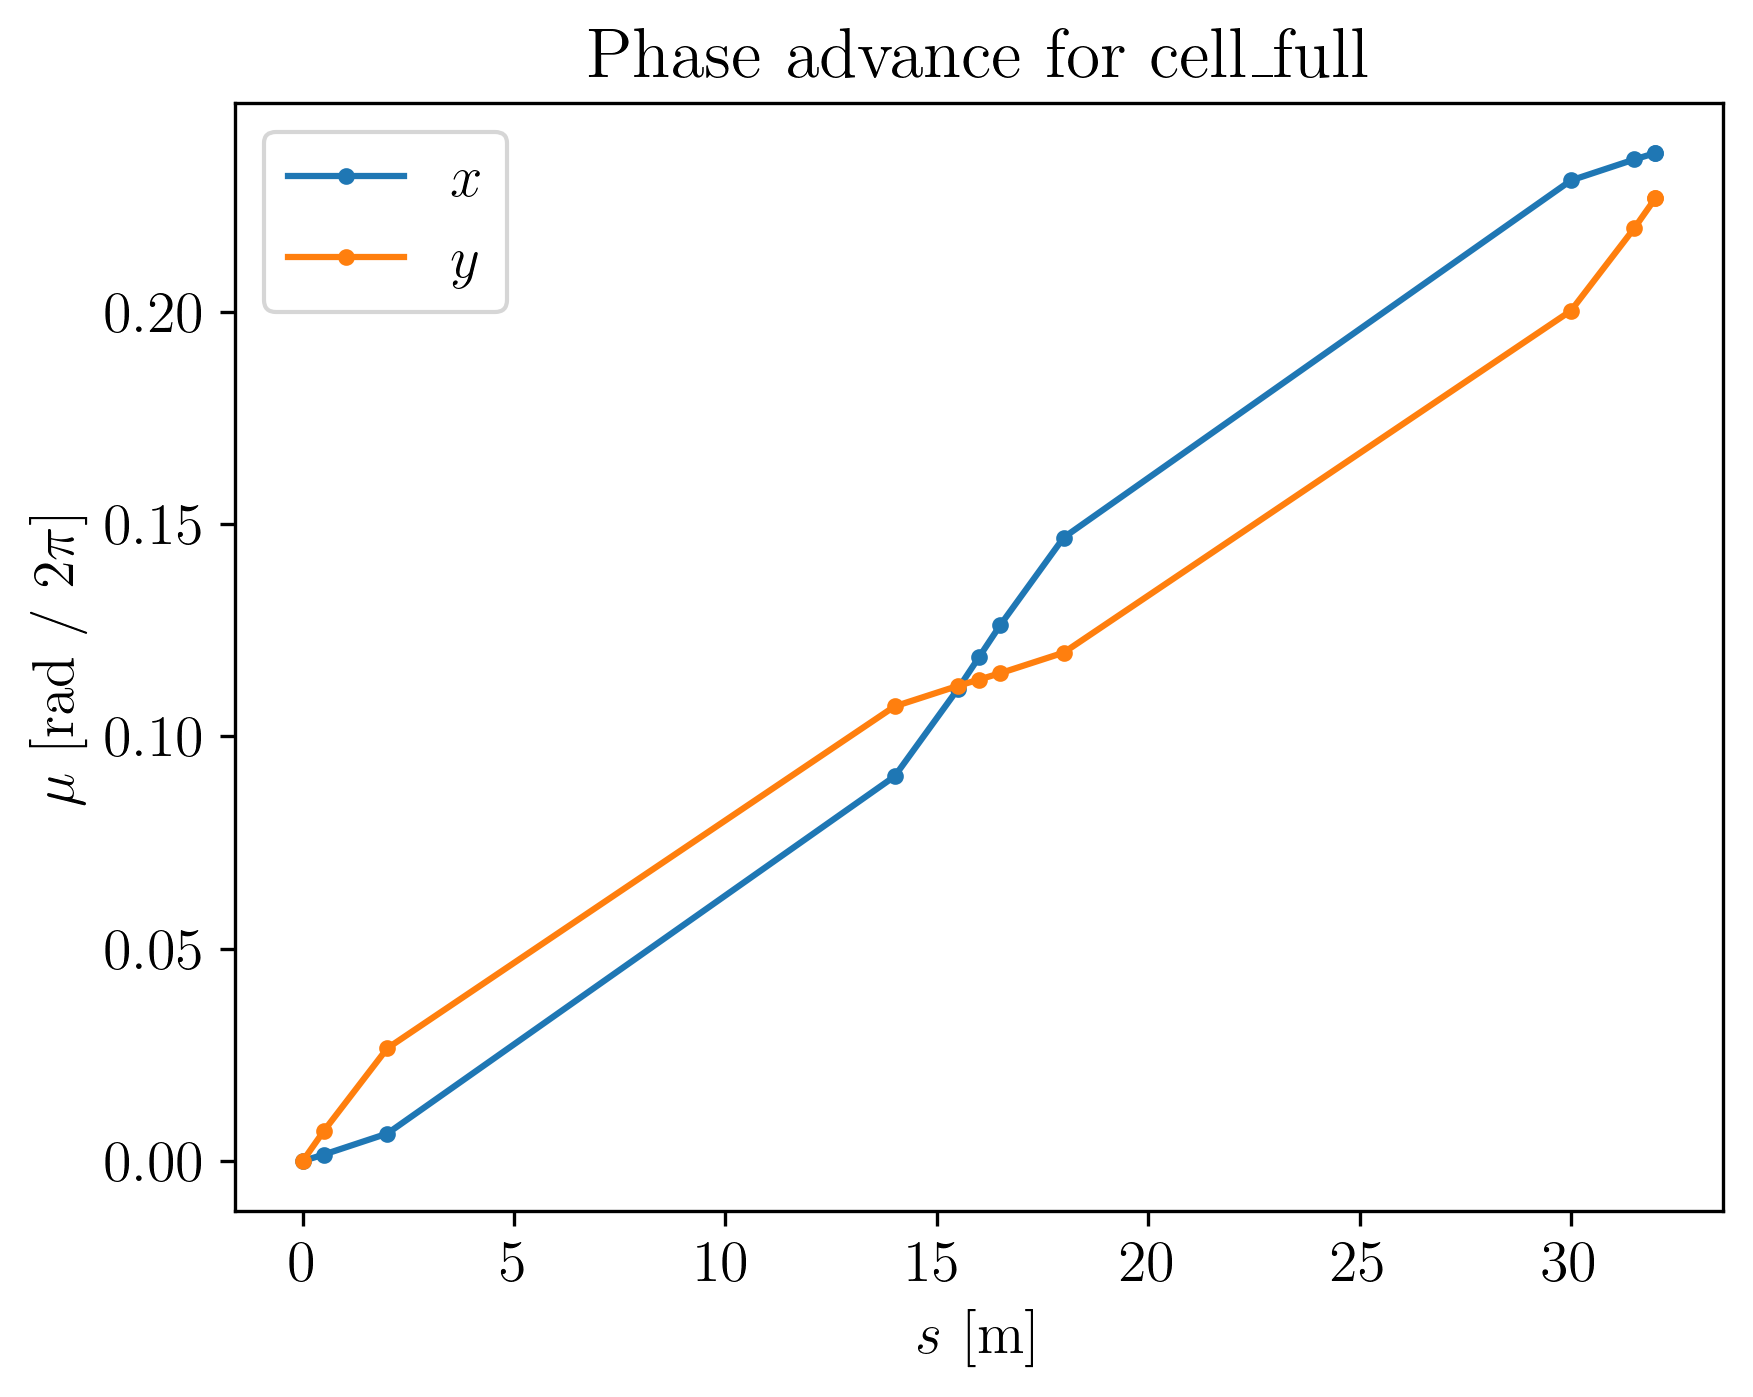

In [4]:
plt.title('Phase advance for cell_full')
plt.plot(twiss.s,twiss.mux,'.-',label='$x$')
plt.plot(twiss.s,twiss.muy,'.-',label='$y$')
plt.ylabel(r'$\mu$ [rad / 2$\pi$]')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

In [12]:
print('H phase advance in degrees:')
print(twiss.mux[-1]*180/pi)
print('V phase advance in degrees:')
print(twiss.muy[-1]*180/pi)

H phase advance in degrees:
13.59900520204786
V phase advance in degrees:
12.99111473934823


### cell_comp:

In [8]:
madx1 = Madx(stdout=False)
madx1.input(f'''
    BEAM, particle=proton, energy=275.0;
    // Geometry
    L_drift  =  1.5;
    L_dipole = 12.0;
    L_quad   =  1.0;
    theta    =  0.036;
    
    L_half_arc_cell  = L_quad +       L_dipole + 2*L_drift;    // Regular arc half cell
    L_half_comp_cell = L_quad + (2/3)*L_dipole + 2*L_drift;    // Compact dispersion suppressor half cell
    
    // Strengths
    kd = 0.084;
    kf = 0.086;
    kdds = kd;
    kfds = kf;
    
    // Drifts
    D:        DRIFT, L =       L_drift;
    D_quart:  DRIFT, L = (1/4)*L_dipole;      // Quarter of the length of a dipole
    DIP_zero: DRIFT, L =       L_dipole;      // A full length, zero angle dipole, aka drift !!
    
    // Dipoles
    DIP_full: SBEND, L =       L_dipole, ANGLE =       theta;  // Nominal arc dipole
    DIP_half: SBEND, L = (1/2)*L_dipole, ANGLE = (1/2)*theta;  // Half length, half angle, full field
    DIP_weak: SBEND, L =       L_dipole, ANGLE = (1/2)*theta;  // Full length, half angle, half field
    DIP_comp:   SBEND, L = (2/3)*L_dipole, ANGLE = (2/3)*theta;  // 2/3  length, 2/3  angle, full field 
    
    // Quadrupoles
    QFH:   QUADRUPOLE, L= 0.5*L_quad, K1 :=  kf;    // Half an arc quad, F
    QDH:   QUADRUPOLE, L= 0.5*L_quad, K1 := -kd;    // Half an arc quad, D
    QFHds: QUADRUPOLE, L= 0.5*L_quad, K1 :=  kfds;  // Half a dispersion suppressor quad, F
    QDHds: QUADRUPOLE, L= 0.5*L_quad, K1 := -kdds;  // Half a dispersion suppressor quad, D
    
    // Beamlines
    interior_full: LINE=(D,          DIP_full,          D); // Interior with a full strength dipole
    interior_half: LINE=(D, D_quart, DIP_half, D_quart, D); // Interior with a half strength dipole
    interior_weak: LINE=(D,          DIP_weak,          D); // Alternate half strength interior
    interior_zero: LINE=(D,          DIP_zero,          D); // Interior with zero bend dipole
    interior_comp: LINE=(D,          DIP_comp,          D); // Compact interior
    
    cell_full: LINE=(QFH,   interior_full,   QDH,QDH,   interior_full, QFH);  // See figure
    cell_half: LINE=(QFH,   interior_half,   QDH,QDH,   interior_half, QFH);
    cell_weak: LINE=(QFH,   interior_weak,   QDH,QDH,   interior_half, QFH);
    cell_zero: LINE=(QFH,   interior_zero,   QDH,QDH,   interior_zero, QFH);
    cell_comp: LINE=(QFHds, interior_comp, QDHds,QDHds, interior_comp, QFHds);
    
    ds_none: LINE=(5*cell_full,              4*cell_zero,              5*cell_full);
    ds_half: LINE=(3*cell_full, 2*cell_half, 4*cell_zero, 2*cell_half, 3*cell_full);
    ds_weak: LINE=(3*cell_full, 2*cell_weak, 4*cell_zero, 2*cell_weak, 3*cell_full);
    ds_comp: LINE=(3*cell_full, 2*cell_comp, 4*cell_zero, 2*cell_comp, 3*cell_full);

    ! B) List and plot Twiss parameters for cell_comp.
    use, sequence = cell_comp;
    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
''')
twiss1 = madx1.table.twiss

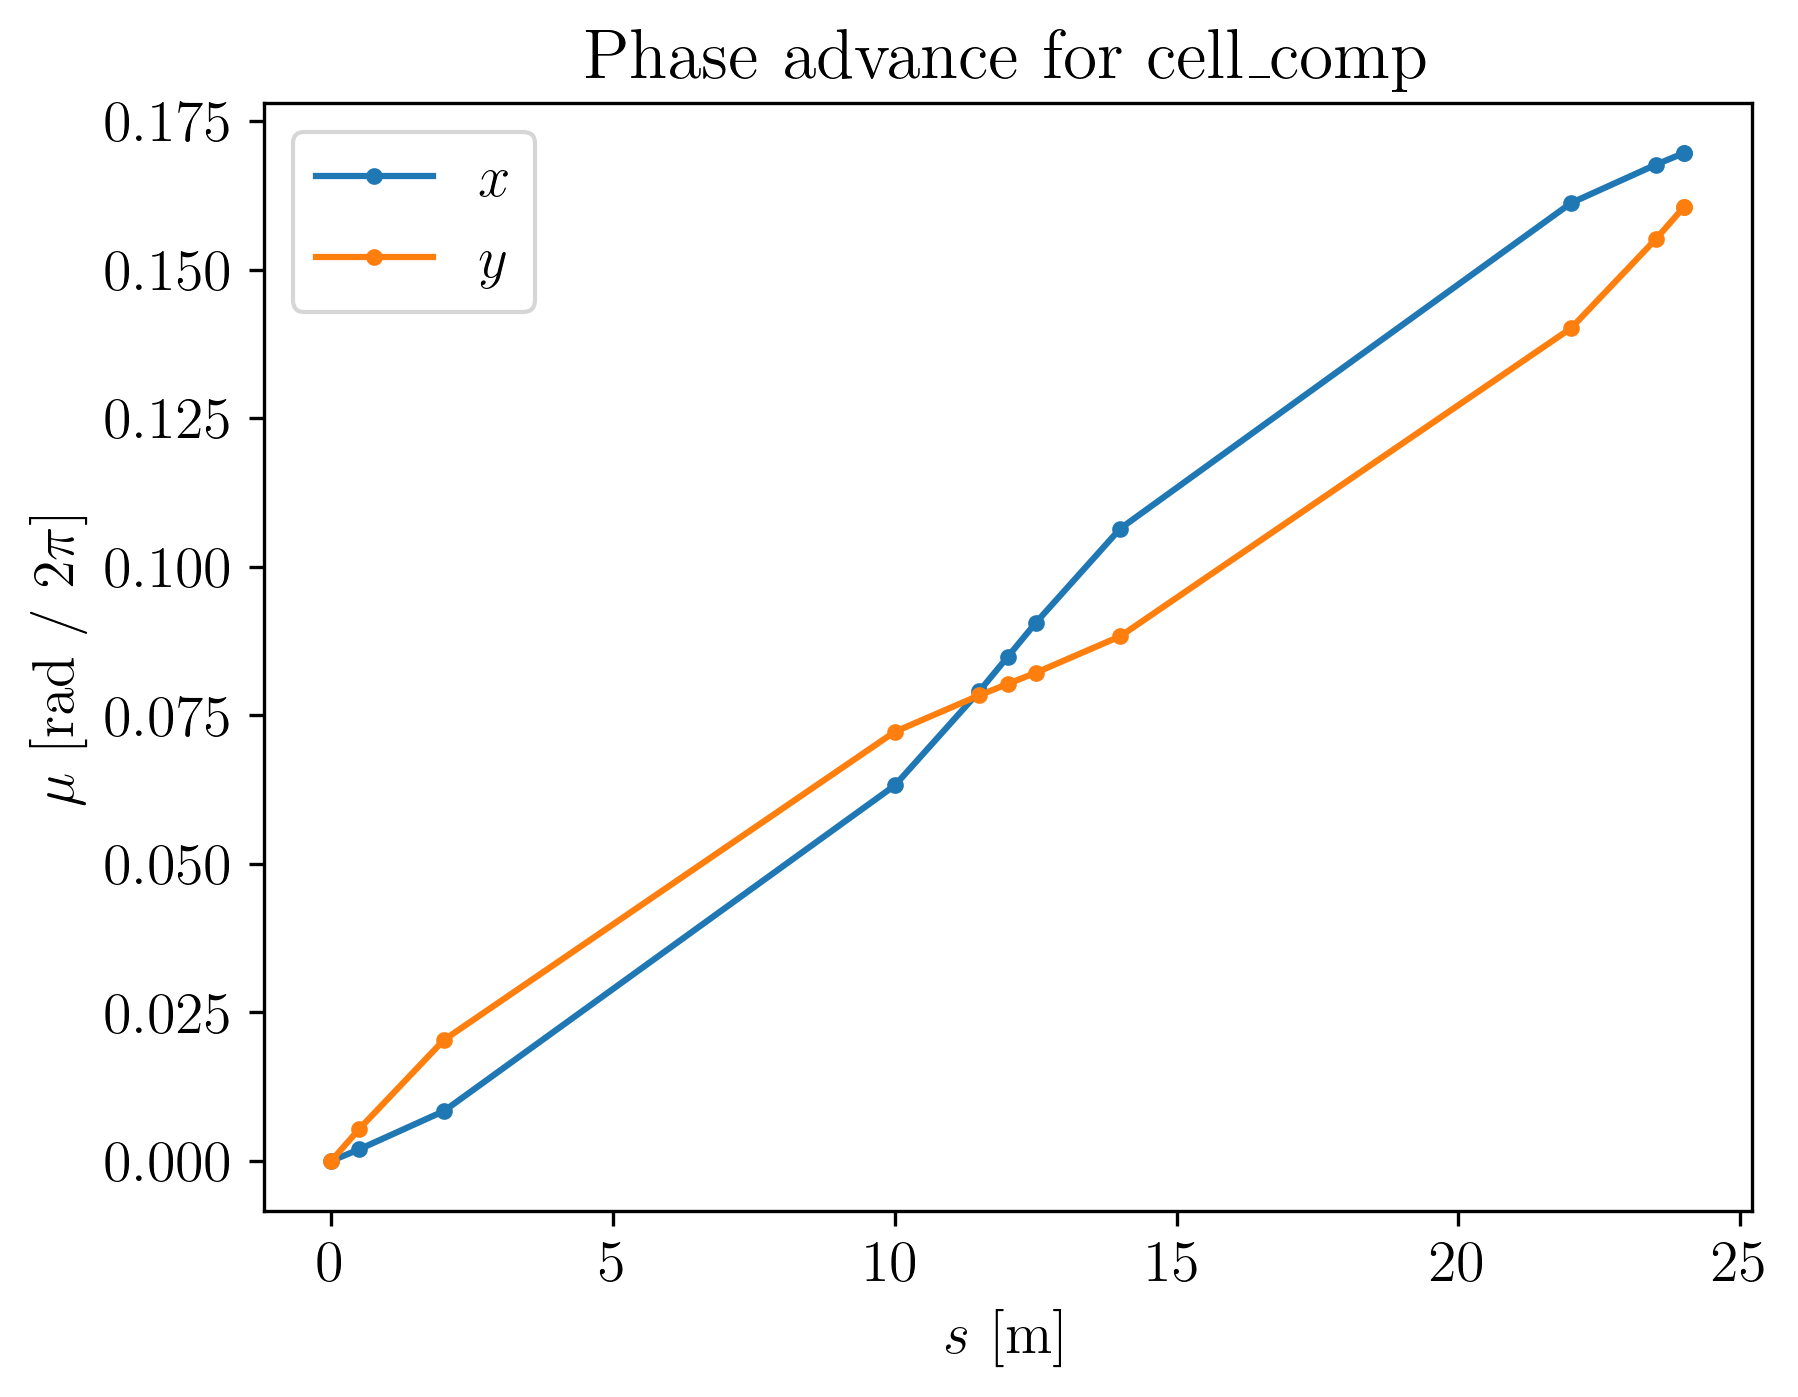

In [9]:
plt.title('Phase advance for cell_comp')
plt.plot(twiss1.s,twiss1.mux,'.-',label='$x$')
plt.plot(twiss1.s,twiss1.muy,'.-',label='$y$')
plt.ylabel(r'$\mu$ [rad / 2$\pi$]')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

In [14]:
print('H phase advance in degrees:')
print(twiss1.mux[-1]*180/pi)
print('V phase advance in degrees:')
print(twiss1.muy[-1]*180/pi)

H phase advance in degrees:
9.722767832467843
V phase advance in degrees:
9.201584796935453


### Observations

- The H and V phase advances are slightly different because the bending dipole only the dynamics along x. To see this effect more clearly, we can adjust theta and study the resulting phase advances.

- For example (see below), we can make theta smaller and see the H phase advance decrease as well (while the V phase advance is unchanged).

In [26]:
madx2 = Madx(stdout=False)
madx2.input(f'''
    BEAM, particle=proton, energy=275.0;
    // Geometry
    L_drift  =  1.5;
    L_dipole = 12.0;
    L_quad   =  1.0;
    theta    =  0.036/4;
    
    L_half_arc_cell  = L_quad +       L_dipole + 2*L_drift;    // Regular arc half cell
    L_half_comp_cell = L_quad + (2/3)*L_dipole + 2*L_drift;    // Compact dispersion suppressor half cell
    
    // Strengths
    kd = 0.084;
    kf = 0.086;
    kdds = kd;
    kfds = kf;
    
    // Drifts
    D:        DRIFT, L =       L_drift;
    D_quart:  DRIFT, L = (1/4)*L_dipole;      // Quarter of the length of a dipole
    DIP_zero: DRIFT, L =       L_dipole;      // A full length, zero angle dipole, aka drift !!
    
    // Dipoles
    DIP_full: SBEND, L =       L_dipole, ANGLE =       theta;  // Nominal arc dipole
    DIP_half: SBEND, L = (1/2)*L_dipole, ANGLE = (1/2)*theta;  // Half length, half angle, full field
    DIP_weak: SBEND, L =       L_dipole, ANGLE = (1/2)*theta;  // Full length, half angle, half field
    DIP_comp:   SBEND, L = (2/3)*L_dipole, ANGLE = (2/3)*theta;  // 2/3  length, 2/3  angle, full field 
    
    // Quadrupoles
    QFH:   QUADRUPOLE, L= 0.5*L_quad, K1 :=  kf;    // Half an arc quad, F
    QDH:   QUADRUPOLE, L= 0.5*L_quad, K1 := -kd;    // Half an arc quad, D
    QFHds: QUADRUPOLE, L= 0.5*L_quad, K1 :=  kfds;  // Half a dispersion suppressor quad, F
    QDHds: QUADRUPOLE, L= 0.5*L_quad, K1 := -kdds;  // Half a dispersion suppressor quad, D
    
    // Beamlines
    interior_full: LINE=(D,          DIP_full,          D); // Interior with a full strength dipole
    interior_half: LINE=(D, D_quart, DIP_half, D_quart, D); // Interior with a half strength dipole
    interior_weak: LINE=(D,          DIP_weak,          D); // Alternate half strength interior
    interior_zero: LINE=(D,          DIP_zero,          D); // Interior with zero bend dipole
    interior_comp: LINE=(D,          DIP_comp,          D); // Compact interior
    
    cell_full: LINE=(QFH,   interior_full,   QDH,QDH,   interior_full, QFH);  // See figure
    cell_half: LINE=(QFH,   interior_half,   QDH,QDH,   interior_half, QFH);
    cell_weak: LINE=(QFH,   interior_weak,   QDH,QDH,   interior_half, QFH);
    cell_zero: LINE=(QFH,   interior_zero,   QDH,QDH,   interior_zero, QFH);
    cell_comp: LINE=(QFHds, interior_comp, QDHds,QDHds, interior_comp, QFHds);
    
    ds_none: LINE=(5*cell_full,              4*cell_zero,              5*cell_full);
    ds_half: LINE=(3*cell_full, 2*cell_half, 4*cell_zero, 2*cell_half, 3*cell_full);
    ds_weak: LINE=(3*cell_full, 2*cell_weak, 4*cell_zero, 2*cell_weak, 3*cell_full);
    ds_comp: LINE=(3*cell_full, 2*cell_comp, 4*cell_zero, 2*cell_comp, 3*cell_full);

    ! B) List and plot Twiss parameters for cell_comp.
    use, sequence = cell_comp;
    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
''')
twiss2 = madx2.table.twiss

In [27]:
print('H phase advance in degrees:')
print(twiss2.mux[-1]*180/pi)
print('V phase advance in degrees:')
print(twiss2.muy[-1]*180/pi)

H phase advance in degrees:
9.707734036033406
V phase advance in degrees:
9.201584796935453


In [28]:
############## loop over a range of theta values and plot (animate?) the change in phase advances ##############

## Case 2 -- enable command block C

### ds_none, 4 straight cells:

In [48]:
madx3 = Madx(stdout=False)
madx3.input(f'''
    BEAM, particle=proton, energy=275.0;
    // Geometry
    L_drift  =  1.5;
    L_dipole = 12.0;
    L_quad   =  1.0;
    theta    =  0.036/4;
    
    L_half_arc_cell  = L_quad +       L_dipole + 2*L_drift;    // Regular arc half cell
    L_half_comp_cell = L_quad + (2/3)*L_dipole + 2*L_drift;    // Compact dispersion suppressor half cell
    
    // Strengths
    kd = 0.084;
    kf = 0.086;
    kdds = kd;
    kfds = kf;
    
    // Drifts
    D:        DRIFT, L =       L_drift;
    D_quart:  DRIFT, L = (1/4)*L_dipole;      // Quarter of the length of a dipole
    DIP_zero: DRIFT, L =       L_dipole;      // A full length, zero angle dipole, aka drift !!
    
    // Dipoles
    DIP_full: SBEND, L =       L_dipole, ANGLE =       theta;  // Nominal arc dipole
    DIP_half: SBEND, L = (1/2)*L_dipole, ANGLE = (1/2)*theta;  // Half length, half angle, full field
    DIP_weak: SBEND, L =       L_dipole, ANGLE = (1/2)*theta;  // Full length, half angle, half field
    DIP_comp:   SBEND, L = (2/3)*L_dipole, ANGLE = (2/3)*theta;  // 2/3  length, 2/3  angle, full field 
    
    // Quadrupoles
    QFH:   QUADRUPOLE, L= 0.5*L_quad, K1 :=  kf;    // Half an arc quad, F
    QDH:   QUADRUPOLE, L= 0.5*L_quad, K1 := -kd;    // Half an arc quad, D
    QFHds: QUADRUPOLE, L= 0.5*L_quad, K1 :=  kfds;  // Half a dispersion suppressor quad, F
    QDHds: QUADRUPOLE, L= 0.5*L_quad, K1 := -kdds;  // Half a dispersion suppressor quad, D
    
    // Beamlines
    interior_full: LINE=(D,          DIP_full,          D); // Interior with a full strength dipole
    interior_half: LINE=(D, D_quart, DIP_half, D_quart, D); // Interior with a half strength dipole
    interior_weak: LINE=(D,          DIP_weak,          D); // Alternate half strength interior
    interior_zero: LINE=(D,          DIP_zero,          D); // Interior with zero bend dipole
    interior_comp: LINE=(D,          DIP_comp,          D); // Compact interior
    
    cell_full: LINE=(QFH,   interior_full,   QDH,QDH,   interior_full, QFH);  // See figure
    cell_half: LINE=(QFH,   interior_half,   QDH,QDH,   interior_half, QFH);
    cell_weak: LINE=(QFH,   interior_weak,   QDH,QDH,   interior_half, QFH);
    cell_zero: LINE=(QFH,   interior_zero,   QDH,QDH,   interior_zero, QFH);
    cell_comp: LINE=(QFHds, interior_comp, QDHds,QDHds, interior_comp, QFHds);
    
    ds_none: LINE=(5*cell_full,              4*cell_zero,              5*cell_full);
    ds_half: LINE=(3*cell_full, 2*cell_half, 4*cell_zero, 2*cell_half, 3*cell_full);
    ds_weak: LINE=(3*cell_full, 2*cell_weak, 4*cell_zero, 2*cell_weak, 3*cell_full);
    ds_comp: LINE=(3*cell_full, 2*cell_comp, 4*cell_zero, 2*cell_comp, 3*cell_full);

    ! B) List and plot Twiss parameters for cell_comp.
    use, sequence = cell_comp;
    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
    
    ! C) List and plot Twiss parameters for a variety of dispersion supressor options

    use, sequence = ds_none;  // goes directly from arc to straight, and back
    !use, sequence = ds_half;  // dispersion suppressor with 2 full length cells of half length, half angle dipoles
    !use, sequence = ds_weak;  // dispersion suppressor with 2 full length cells of full length, half angle dipoles
    !use, sequence = ds_comp;  // dispersion suppressor with 2 compact cells of      3/4 length,  2/3 angle dipoles

    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
    plot,   interpolate, haxis=s, hmax=500, vaxis1=betx,bety, vaxis2=dx, colour=100, file = disp_supp;

    stop;

''')
twiss3 = madx3.table.twiss

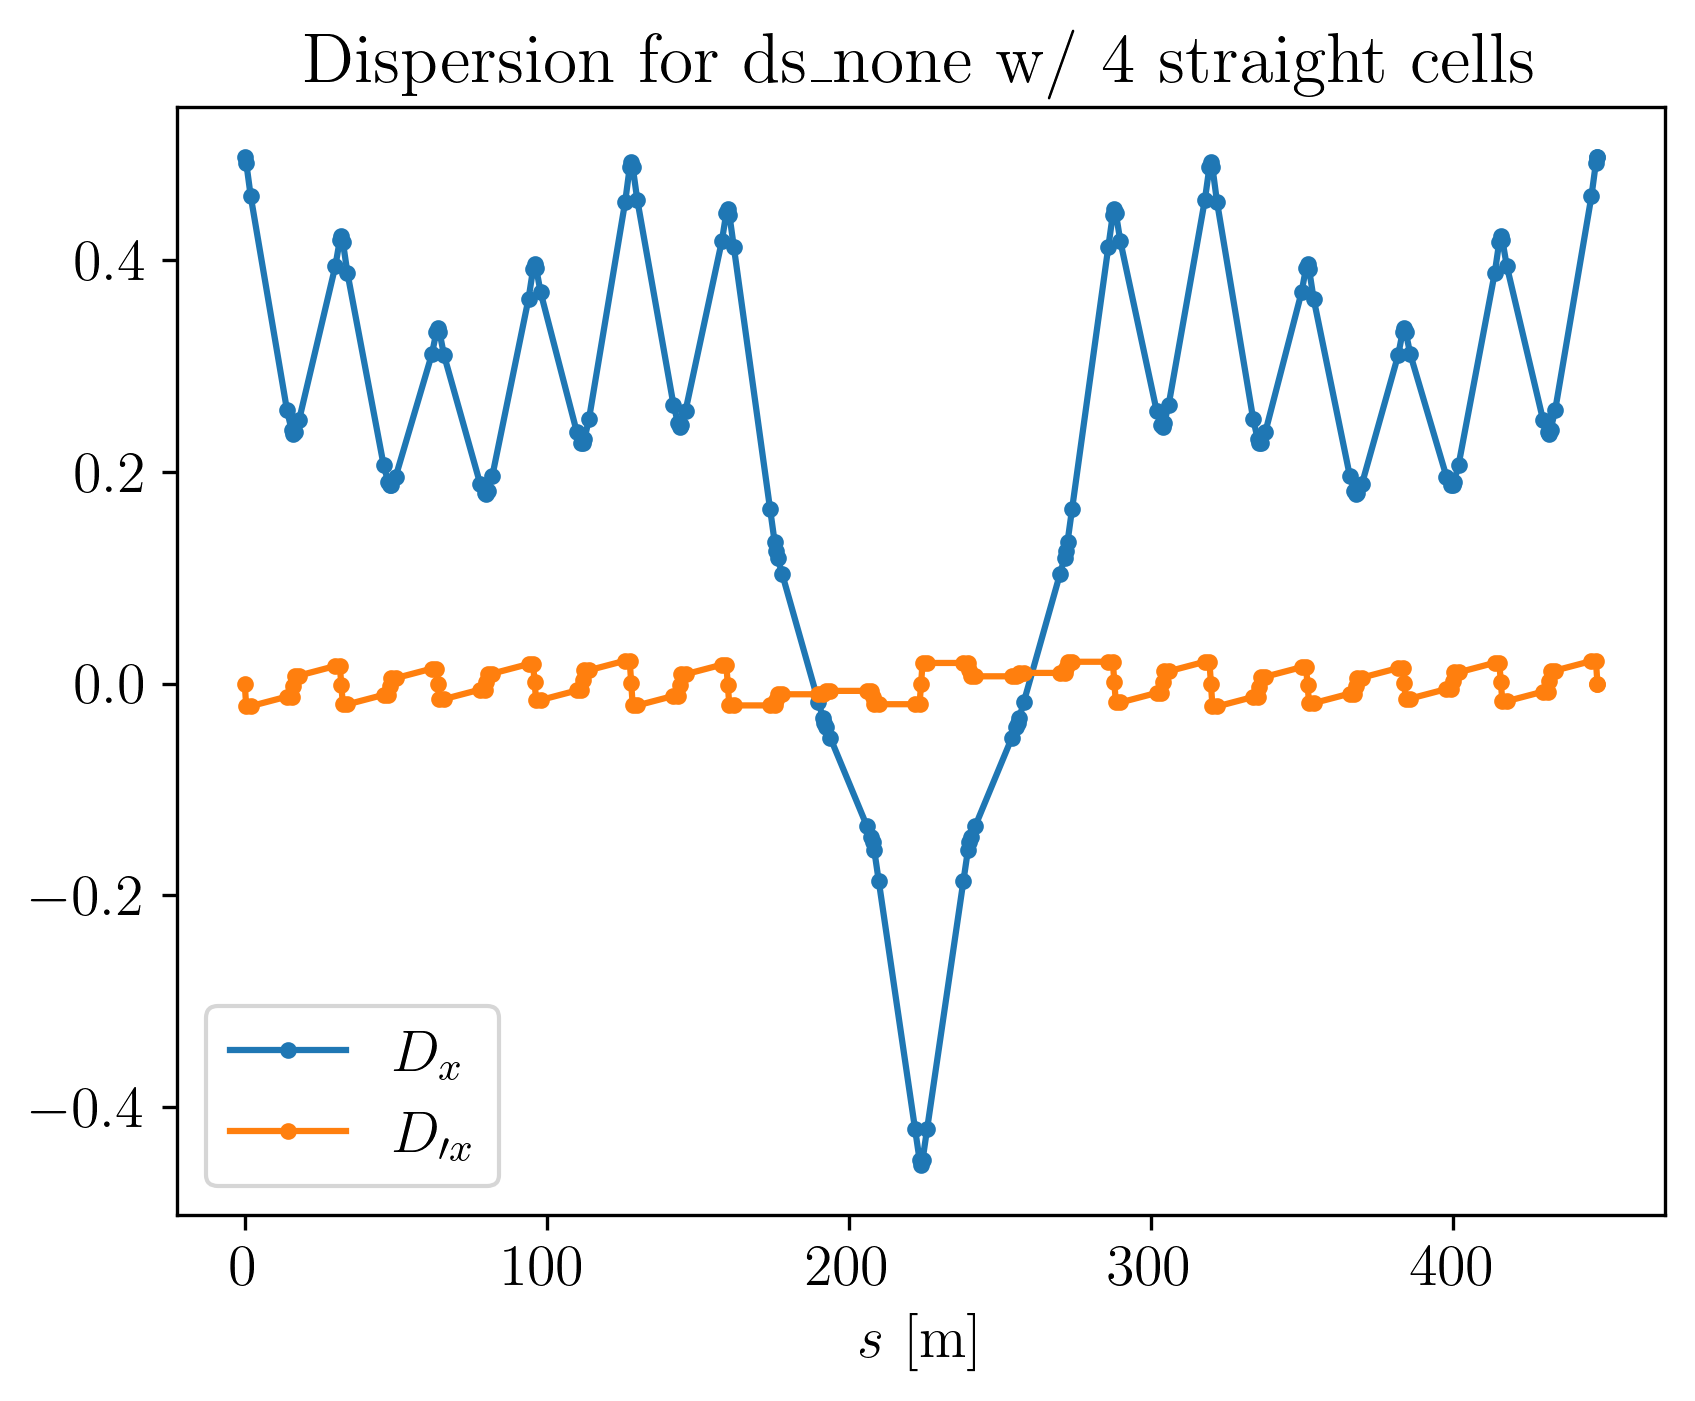

In [49]:
plt.title('Dispersion for ds_none w/ 4 straight cells')
plt.plot(twiss3.s,twiss3.dx,'.-',label='$D_x$')
plt.plot(twiss3.s,twiss3.dpx,'.-',label='$D_{\prime x}$')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

The lattice is composed of arc cells $\rightarrow$ straight cells $\rightarrow$ arc cells. 

$\implies$ We expect the dispersion to go to zero (or nearly zero) around the center if ds_none is suppressing the dispersion -- which it does not.

$\therefore$ ds_none does NOT work as a dispersion suppressor.

### ds_none, 8 straight cells:

In [54]:
madx4 = Madx(stdout=False)
madx4.input(f'''
    BEAM, particle=proton, energy=275.0;
    // Geometry
    L_drift  =  1.5;
    L_dipole = 12.0;
    L_quad   =  1.0;
    theta    =  0.036/4;
    
    L_half_arc_cell  = L_quad +       L_dipole + 2*L_drift;    // Regular arc half cell
    L_half_comp_cell = L_quad + (2/3)*L_dipole + 2*L_drift;    // Compact dispersion suppressor half cell
    
    // Strengths
    kd = 0.084;
    kf = 0.086;
    kdds = kd;
    kfds = kf;
    
    // Drifts
    D:        DRIFT, L =       L_drift;
    D_quart:  DRIFT, L = (1/4)*L_dipole;      // Quarter of the length of a dipole
    DIP_zero: DRIFT, L =       L_dipole;      // A full length, zero angle dipole, aka drift !!
    
    // Dipoles
    DIP_full: SBEND, L =       L_dipole, ANGLE =       theta;  // Nominal arc dipole
    DIP_half: SBEND, L = (1/2)*L_dipole, ANGLE = (1/2)*theta;  // Half length, half angle, full field
    DIP_weak: SBEND, L =       L_dipole, ANGLE = (1/2)*theta;  // Full length, half angle, half field
    DIP_comp:   SBEND, L = (2/3)*L_dipole, ANGLE = (2/3)*theta;  // 2/3  length, 2/3  angle, full field 
    
    // Quadrupoles
    QFH:   QUADRUPOLE, L= 0.5*L_quad, K1 :=  kf;    // Half an arc quad, F
    QDH:   QUADRUPOLE, L= 0.5*L_quad, K1 := -kd;    // Half an arc quad, D
    QFHds: QUADRUPOLE, L= 0.5*L_quad, K1 :=  kfds;  // Half a dispersion suppressor quad, F
    QDHds: QUADRUPOLE, L= 0.5*L_quad, K1 := -kdds;  // Half a dispersion suppressor quad, D
    
    // Beamlines
    interior_full: LINE=(D,          DIP_full,          D); // Interior with a full strength dipole
    interior_half: LINE=(D, D_quart, DIP_half, D_quart, D); // Interior with a half strength dipole
    interior_weak: LINE=(D,          DIP_weak,          D); // Alternate half strength interior
    interior_zero: LINE=(D,          DIP_zero,          D); // Interior with zero bend dipole
    interior_comp: LINE=(D,          DIP_comp,          D); // Compact interior
    
    cell_full: LINE=(QFH,   interior_full,   QDH,QDH,   interior_full, QFH);  // See figure
    cell_half: LINE=(QFH,   interior_half,   QDH,QDH,   interior_half, QFH);
    cell_weak: LINE=(QFH,   interior_weak,   QDH,QDH,   interior_half, QFH);
    cell_zero: LINE=(QFH,   interior_zero,   QDH,QDH,   interior_zero, QFH);
    cell_comp: LINE=(QFHds, interior_comp, QDHds,QDHds, interior_comp, QFHds);
    
    ds_none: LINE=(5*cell_full,              8*cell_zero,              5*cell_full);
    ds_half: LINE=(3*cell_full, 2*cell_half, 4*cell_zero, 2*cell_half, 3*cell_full);
    ds_weak: LINE=(3*cell_full, 2*cell_weak, 4*cell_zero, 2*cell_weak, 3*cell_full);
    ds_comp: LINE=(3*cell_full, 2*cell_comp, 4*cell_zero, 2*cell_comp, 3*cell_full);

    ! B) List and plot Twiss parameters for cell_comp.
    use, sequence = cell_comp;
    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
    
    ! C) List and plot Twiss parameters for a variety of dispersion supressor options

    use, sequence = ds_none;  // goes directly from arc to straight, and back
    !use, sequence = ds_half;  // dispersion suppressor with 2 full length cells of half length, half angle dipoles
    !use, sequence = ds_weak;  // dispersion suppressor with 2 full length cells of full length, half angle dipoles
    !use, sequence = ds_comp;  // dispersion suppressor with 2 compact cells of      3/4 length,  2/3 angle dipoles

    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
    plot,   interpolate, haxis=s, hmax=500, vaxis1=betx,bety, vaxis2=dx, colour=100, file = disp_supp;

    stop;

''')
twiss4 = madx4.table.twiss

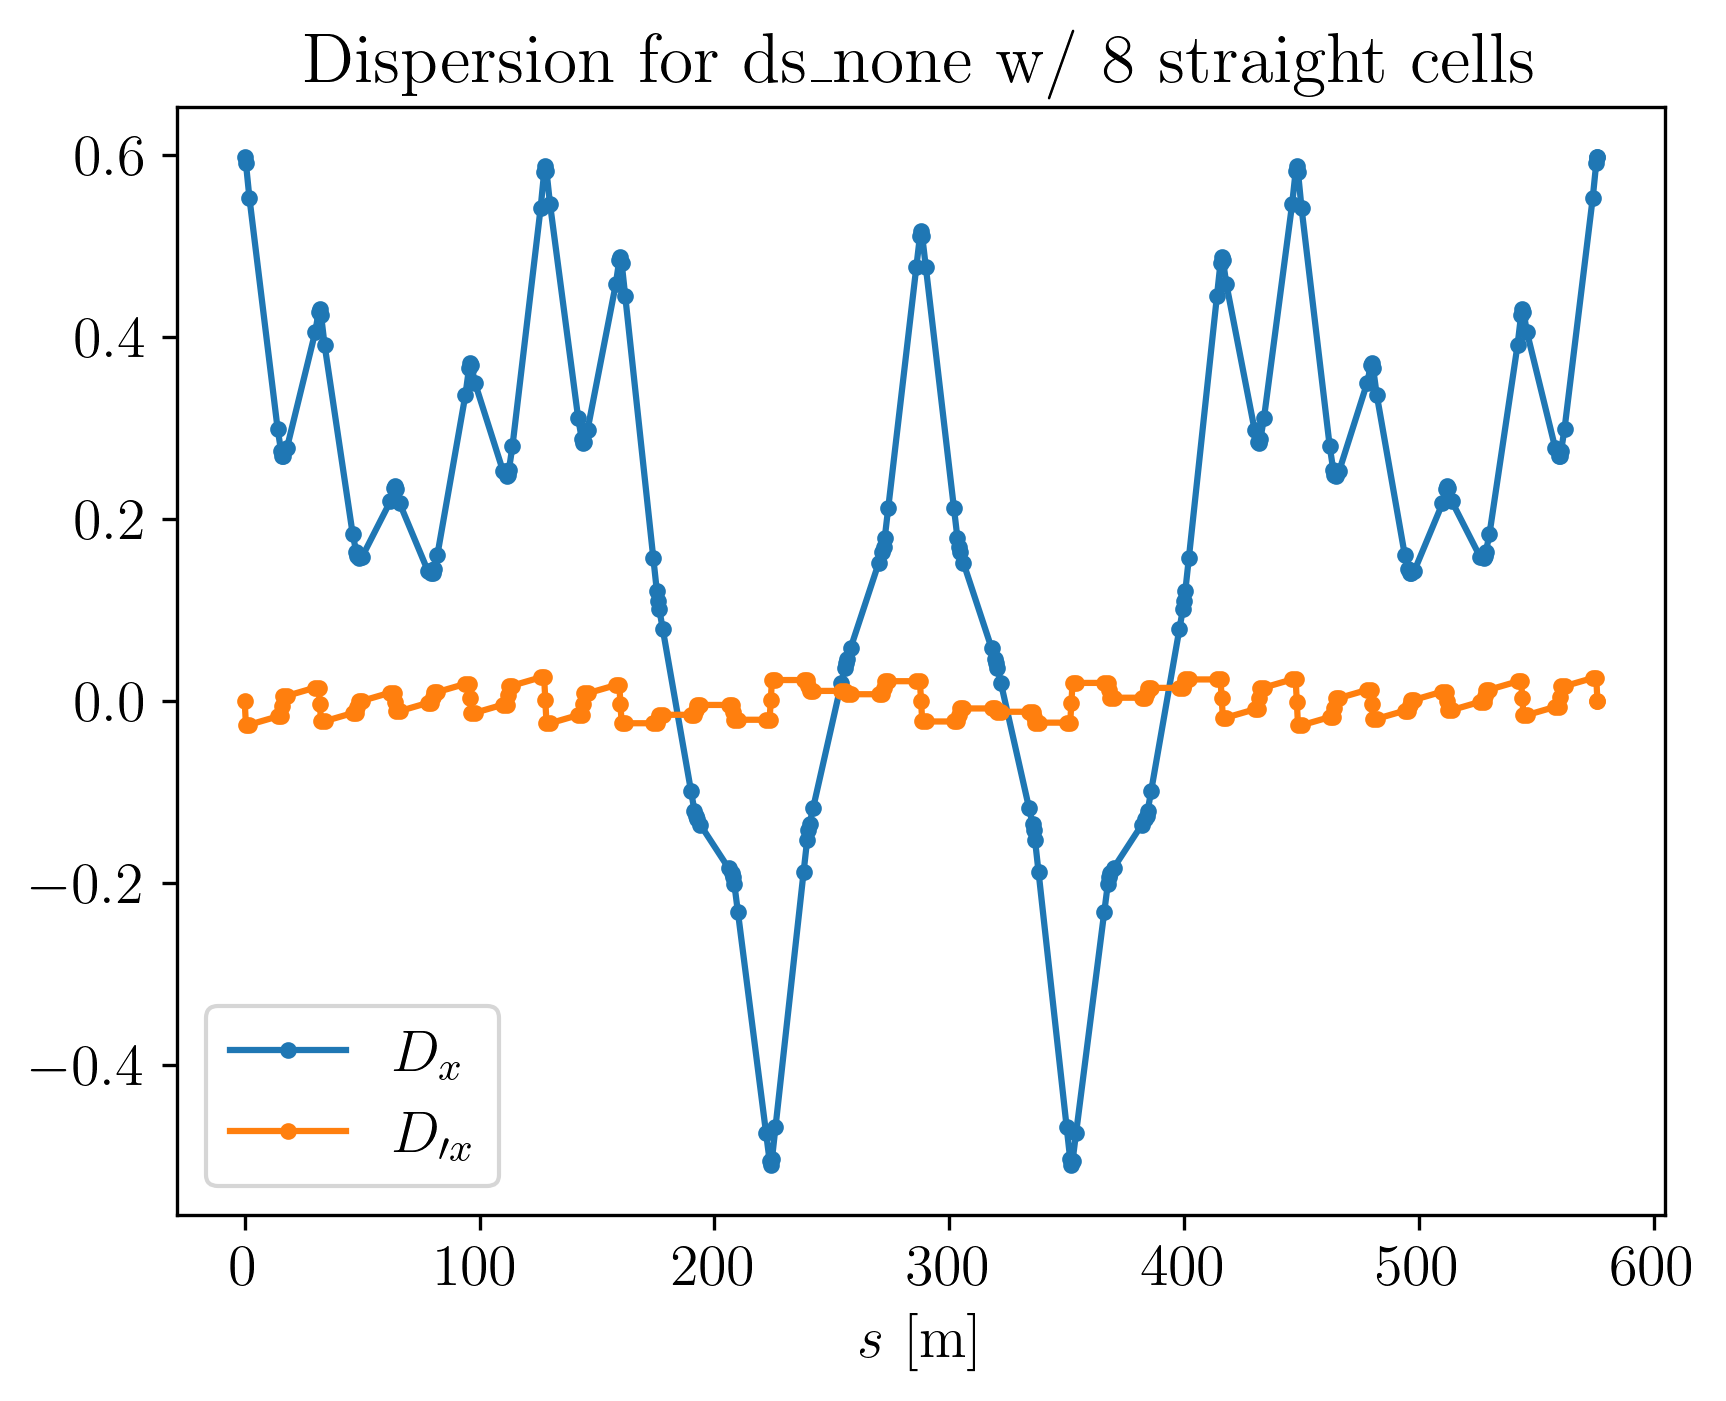

In [55]:
plt.title('Dispersion for ds_none w/ 8 straight cells')
plt.plot(twiss4.s,twiss4.dx,'.-',label='$D_x$')
plt.plot(twiss4.s,twiss4.dpx,'.-',label='$D_{\prime x}$')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

The dispersion no longer goes to zero at the center of the lattice -- in fact, we see the dispersion reach a local maximum and execute rather large oscillations in the straight section.

$\therefore$ Increasing the number of straight cells $\implies$ ds_none is does not function as a dispersion suppressor.

### ds_half:

In [60]:
madx5 = Madx(stdout=False)
madx5.input(f'''
    BEAM, particle=proton, energy=275.0;
    // Geometry
    L_drift  =  1.5;
    L_dipole = 12.0;
    L_quad   =  1.0;
    theta    =  0.036/4;
    
    L_half_arc_cell  = L_quad +       L_dipole + 2*L_drift;    // Regular arc half cell
    L_half_comp_cell = L_quad + (2/3)*L_dipole + 2*L_drift;    // Compact dispersion suppressor half cell
    
    // Strengths
    kd = 0.084;
    kf = 0.086;
    kdds = kd;
    kfds = kf;
    
    // Drifts
    D:        DRIFT, L =       L_drift;
    D_quart:  DRIFT, L = (1/4)*L_dipole;      // Quarter of the length of a dipole
    DIP_zero: DRIFT, L =       L_dipole;      // A full length, zero angle dipole, aka drift !!
    
    // Dipoles
    DIP_full: SBEND, L =       L_dipole, ANGLE =       theta;  // Nominal arc dipole
    DIP_half: SBEND, L = (1/2)*L_dipole, ANGLE = (1/2)*theta;  // Half length, half angle, full field
    DIP_weak: SBEND, L =       L_dipole, ANGLE = (1/2)*theta;  // Full length, half angle, half field
    DIP_comp:   SBEND, L = (2/3)*L_dipole, ANGLE = (2/3)*theta;  // 2/3  length, 2/3  angle, full field 
    
    // Quadrupoles
    QFH:   QUADRUPOLE, L= 0.5*L_quad, K1 :=  kf;    // Half an arc quad, F
    QDH:   QUADRUPOLE, L= 0.5*L_quad, K1 := -kd;    // Half an arc quad, D
    QFHds: QUADRUPOLE, L= 0.5*L_quad, K1 :=  kfds;  // Half a dispersion suppressor quad, F
    QDHds: QUADRUPOLE, L= 0.5*L_quad, K1 := -kdds;  // Half a dispersion suppressor quad, D
    
    // Beamlines
    interior_full: LINE=(D,          DIP_full,          D); // Interior with a full strength dipole
    interior_half: LINE=(D, D_quart, DIP_half, D_quart, D); // Interior with a half strength dipole
    interior_weak: LINE=(D,          DIP_weak,          D); // Alternate half strength interior
    interior_zero: LINE=(D,          DIP_zero,          D); // Interior with zero bend dipole
    interior_comp: LINE=(D,          DIP_comp,          D); // Compact interior
    
    cell_full: LINE=(QFH,   interior_full,   QDH,QDH,   interior_full, QFH);  // See figure
    cell_half: LINE=(QFH,   interior_half,   QDH,QDH,   interior_half, QFH);
    cell_weak: LINE=(QFH,   interior_weak,   QDH,QDH,   interior_half, QFH);
    cell_zero: LINE=(QFH,   interior_zero,   QDH,QDH,   interior_zero, QFH);
    cell_comp: LINE=(QFHds, interior_comp, QDHds,QDHds, interior_comp, QFHds);
    
    ds_none: LINE=(5*cell_full,              4*cell_zero,              5*cell_full);
    ds_half: LINE=(3*cell_full, 2*cell_half, 4*cell_zero, 2*cell_half, 3*cell_full);
    ds_weak: LINE=(3*cell_full, 2*cell_weak, 4*cell_zero, 2*cell_weak, 3*cell_full);
    ds_comp: LINE=(3*cell_full, 2*cell_comp, 4*cell_zero, 2*cell_comp, 3*cell_full);

    ! B) List and plot Twiss parameters for cell_comp.
    use, sequence = cell_comp;
    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
    
    ! C) List and plot Twiss parameters for a variety of dispersion supressor options

    !use, sequence = ds_none;  // goes directly from arc to straight, and back
    use, sequence = ds_half;  // dispersion suppressor with 2 full length cells of half length, half angle dipoles
    !use, sequence = ds_weak;  // dispersion suppressor with 2 full length cells of full length, half angle dipoles
    !use, sequence = ds_comp;  // dispersion suppressor with 2 compact cells of      3/4 length,  2/3 angle dipoles

    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
    plot,   interpolate, haxis=s, hmax=500, vaxis1=betx,bety, vaxis2=dx, colour=100, file = disp_supp;

    stop;

''')
twiss5 = madx5.table.twiss

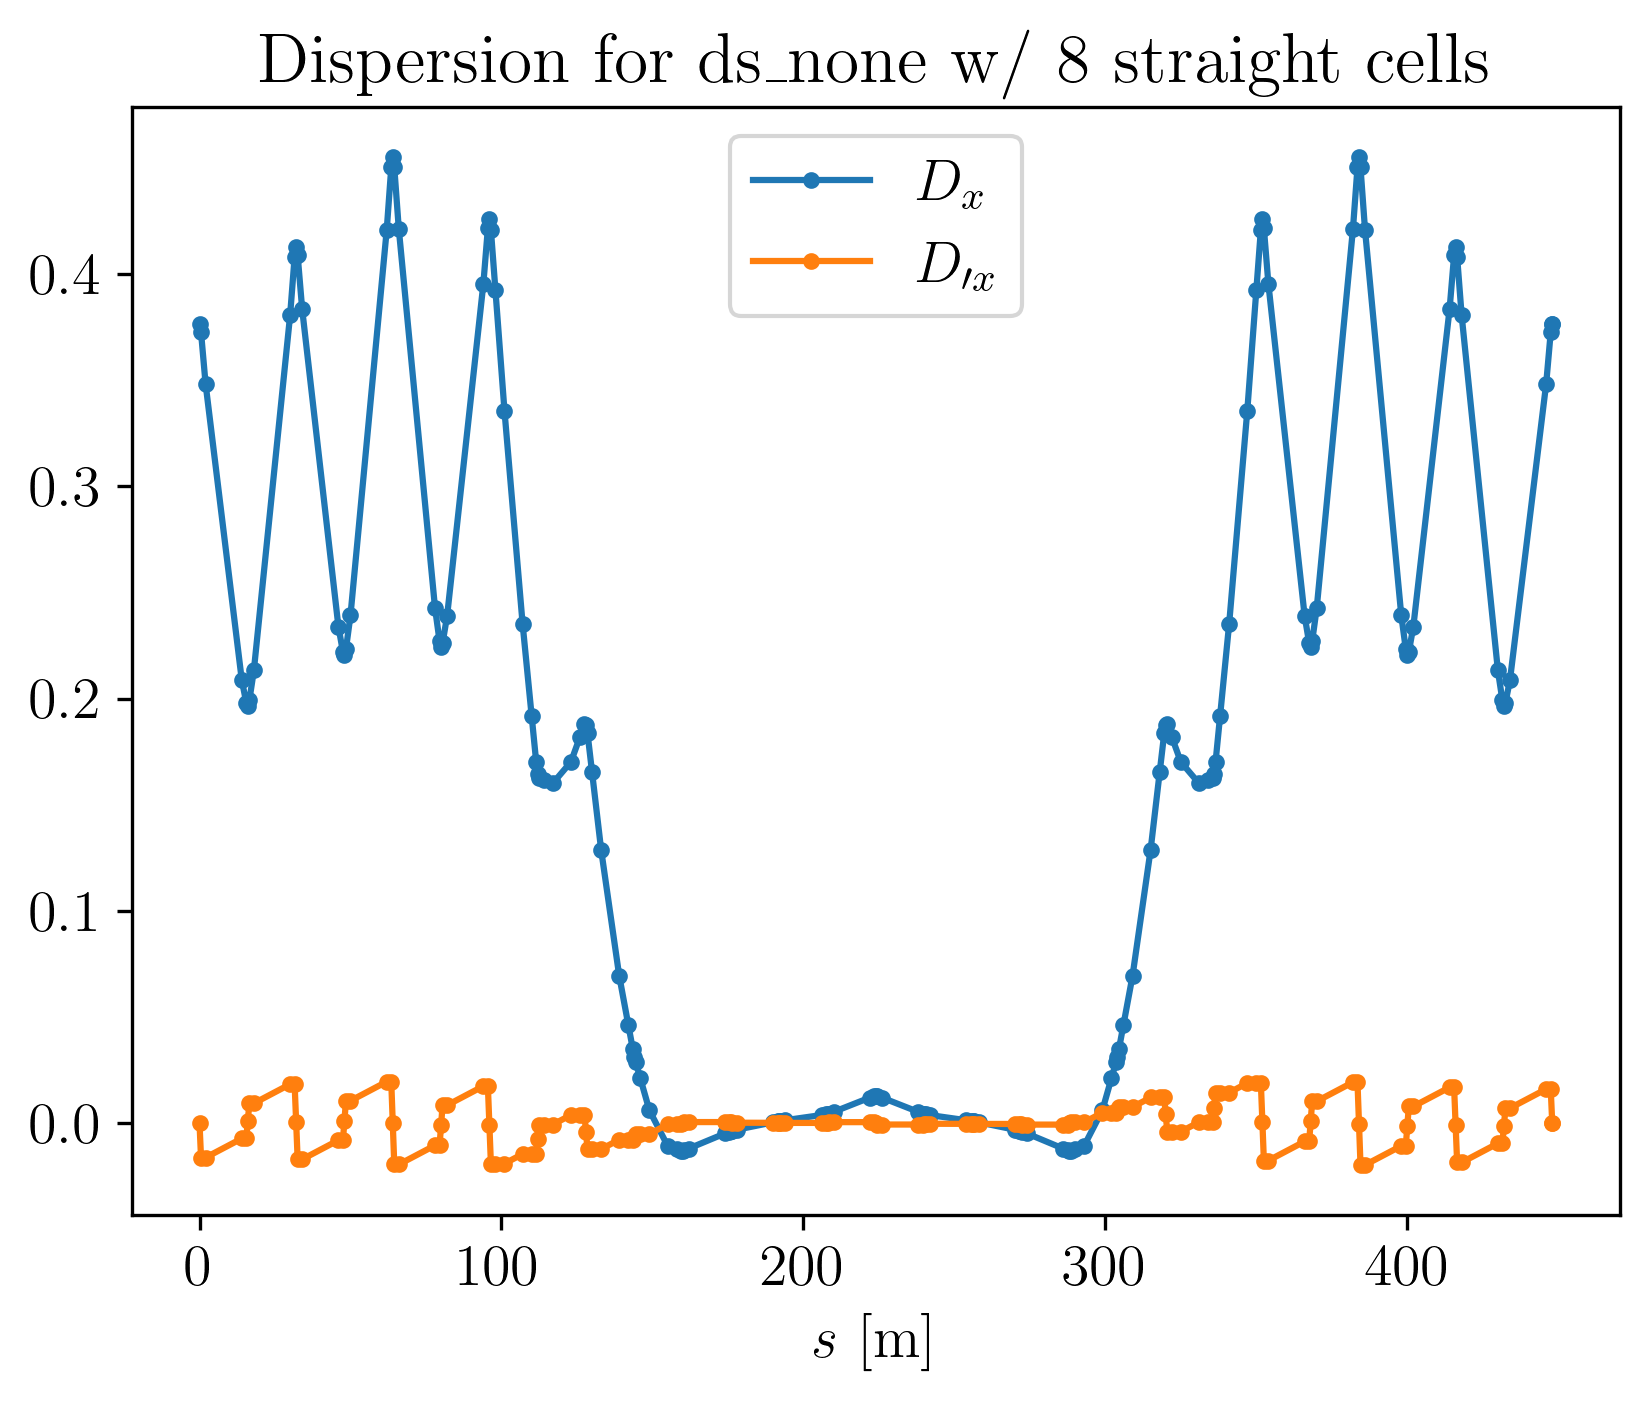

In [61]:
plt.title('Dispersion for ds_none w/ 8 straight cells')
plt.plot(twiss5.s,twiss5.dx,'.-',label='$D_x$')
plt.plot(twiss5.s,twiss5.dpx,'.-',label='$D_{\prime x}$')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

Dispersion $\rightarrow 0$ in the straight section $\implies$ ds_half functions as a dispersion suppressor.

## Case 3 -- enable command block A

### ds_half:

In [8]:
madx6 = Madx(stdout=False)
madx6.input(f'''
    BEAM, particle=proton, energy=275.0;
    // Geometry
    L_drift  =  1.5;
    L_dipole = 12.0;
    L_quad   =  1.0;
    theta    =  0.036/4;
    
    L_half_arc_cell  = L_quad +       L_dipole + 2*L_drift;    // Regular arc half cell
    L_half_comp_cell = L_quad + (2/3)*L_dipole + 2*L_drift;    // Compact dispersion suppressor half cell
    
    // Strengths
    kd = 0.084;
    kf = 0.086;
    kdds = kd;
    kfds = kf;
    
    // Drifts
    D:        DRIFT, L =       L_drift;
    D_quart:  DRIFT, L = (1/4)*L_dipole;      // Quarter of the length of a dipole
    DIP_zero: DRIFT, L =       L_dipole;      // A full length, zero angle dipole, aka drift !!
    
    // Dipoles
    DIP_full: SBEND, L =       L_dipole, ANGLE =       theta;  // Nominal arc dipole
    DIP_half: SBEND, L = (1/2)*L_dipole, ANGLE = (1/2)*theta;  // Half length, half angle, full field
    DIP_weak: SBEND, L =       L_dipole, ANGLE = (1/2)*theta;  // Full length, half angle, half field
    DIP_comp:   SBEND, L = (2/3)*L_dipole, ANGLE = (2/3)*theta;  // 2/3  length, 2/3  angle, full field 
    
    // Quadrupoles
    QFH:   QUADRUPOLE, L= 0.5*L_quad, K1 :=  kf;    // Half an arc quad, F
    QDH:   QUADRUPOLE, L= 0.5*L_quad, K1 := -kd;    // Half an arc quad, D
    QFHds: QUADRUPOLE, L= 0.5*L_quad, K1 :=  kfds;  // Half a dispersion suppressor quad, F
    QDHds: QUADRUPOLE, L= 0.5*L_quad, K1 := -kdds;  // Half a dispersion suppressor quad, D
    
    // Beamlines
    interior_full: LINE=(D,          DIP_full,          D); // Interior with a full strength dipole
    interior_half: LINE=(D, D_quart, DIP_half, D_quart, D); // Interior with a half strength dipole
    interior_weak: LINE=(D,          DIP_weak,          D); // Alternate half strength interior
    interior_zero: LINE=(D,          DIP_zero,          D); // Interior with zero bend dipole
    interior_comp: LINE=(D,          DIP_comp,          D); // Compact interior
    
    cell_full: LINE=(QFH,   interior_full,   QDH,QDH,   interior_full, QFH);  // See figure
    cell_half: LINE=(QFH,   interior_half,   QDH,QDH,   interior_half, QFH);
    cell_weak: LINE=(QFH,   interior_weak,   QDH,QDH,   interior_half, QFH);
    cell_zero: LINE=(QFH,   interior_zero,   QDH,QDH,   interior_zero, QFH);
    cell_comp: LINE=(QFHds, interior_comp, QDHds,QDHds, interior_comp, QFHds);
    
    ds_none: LINE=(5*cell_full,              4*cell_zero,              5*cell_full);
    ds_half: LINE=(3*cell_full, 2*cell_half, 4*cell_zero, 2*cell_half, 3*cell_full);
    ds_weak: LINE=(3*cell_full, 2*cell_weak, 4*cell_zero, 2*cell_weak, 3*cell_full);
    ds_comp: LINE=(3*cell_full, 2*cell_comp, 4*cell_zero, 2*cell_comp, 3*cell_full);

    ! A) Find the quadrupole strengths that achieve the desired H & V phase advances per cell

    mux_goal = 0.125;
    muy_goal = 0.22;
    
    use, period = cell_full;
    match, sequence = cell_full;
           constraint, sequence = cell_full, range = #e, mux = mux_goal, muy = muy_goal;
           vary, name = kd, step = 0.000001;
           vary, name = kf, step = 0.000001;
           lmdif, calls = 5000, tolerance = 1.e-12;
    endmatch;
    print,  text = " ";
    print,  text = "AFTER MATCHING ARC CELL";
    printf, text = "Quad strengths in arc: kd,   kf   = %10.6f, %10.6f", value = kd, kf;
    
    use, period = cell_comp;
    match, sequence = cell_comp;
           constraint, sequence = cell_comp, range = #e, mux = mux_goal, muy = muy_goal;
           vary, name = kdds, step = 0.000001;
           vary, name = kfds, step = 0.000001;
           lmdif, calls = 5000, tolerance = 1.e-12;
    endmatch;
    print,  text = " ";
    print,  text = "AFTER MATCHING DISPERSION SUPPRESSOR CELL";
    printf, text = "Quad strengths in comp:  kdds, kfds = %10.6f, %10.6f", value = kdds, kfds;

    ! B) List and plot Twiss parameters for cell_comp.
    use, sequence = cell_comp;
    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
    
    ! C) List and plot Twiss parameters for a variety of dispersion supressor options

    !use, sequence = ds_none;  // goes directly from arc to straight, and back
    use, sequence = ds_half;  // dispersion suppressor with 2 full length cells of half length, half angle dipoles
    !use, sequence = ds_weak;  // dispersion suppressor with 2 full length cells of full length, half angle dipoles
    !use, sequence = ds_comp;  // dispersion suppressor with 2 compact cells of      3/4 length,  2/3 angle dipoles

    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
    plot,   interpolate, haxis=s, hmax=500, vaxis1=betx,bety, vaxis2=dx, colour=100, file = disp_supp;

    stop;

''')
twiss6 = madx6.table.twiss

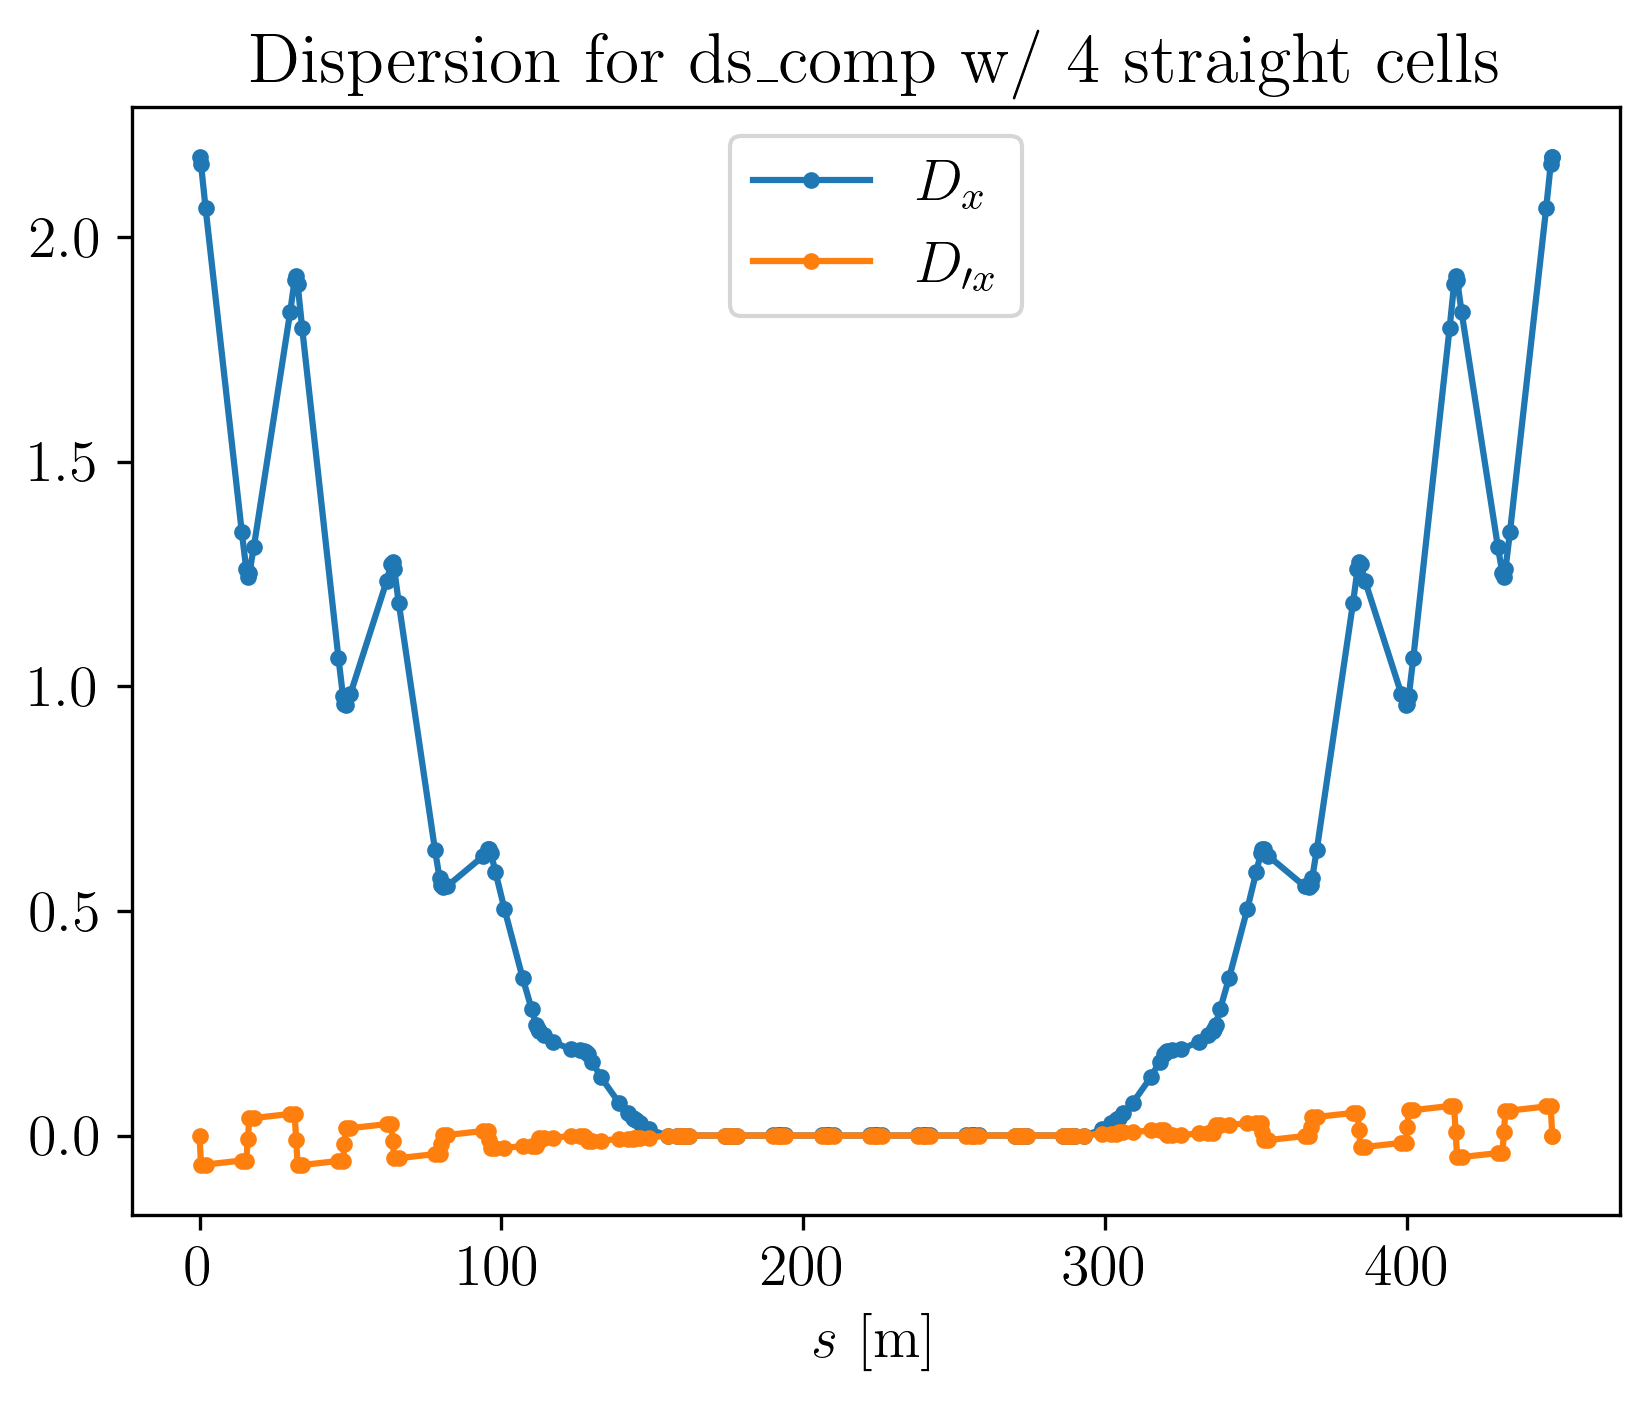

In [9]:
plt.title('Dispersion for ds_comp w/ 4 straight cells')
plt.plot(twiss6.s,twiss6.dx,'.-',label='$D_x$')
plt.plot(twiss6.s,twiss6.dpx,'.-',label='$D_{\prime x}$')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

Based on hand-tuning, the value of $\mu_x$ that optimizes ds_half performance is around $\boxed{0.125}$.

The value of $\mu_y$ has little to no impact on the performance of ds_half because the dispersion acts in the x-direction.

### ds_weak:

In [10]:
madx7 = Madx(stdout=False)
madx7.input(f'''
    BEAM, particle=proton, energy=275.0;
    // Geometry
    L_drift  =  1.5;
    L_dipole = 12.0;
    L_quad   =  1.0;
    theta    =  0.036/4;
    
    L_half_arc_cell  = L_quad +       L_dipole + 2*L_drift;    // Regular arc half cell
    L_half_comp_cell = L_quad + (2/3)*L_dipole + 2*L_drift;    // Compact dispersion suppressor half cell
    
    // Strengths
    kd = 0.084;
    kf = 0.086;
    kdds = kd;
    kfds = kf;
    
    // Drifts
    D:        DRIFT, L =       L_drift;
    D_quart:  DRIFT, L = (1/4)*L_dipole;      // Quarter of the length of a dipole
    DIP_zero: DRIFT, L =       L_dipole;      // A full length, zero angle dipole, aka drift !!
    
    // Dipoles
    DIP_full: SBEND, L =       L_dipole, ANGLE =       theta;  // Nominal arc dipole
    DIP_half: SBEND, L = (1/2)*L_dipole, ANGLE = (1/2)*theta;  // Half length, half angle, full field
    DIP_weak: SBEND, L =       L_dipole, ANGLE = (1/2)*theta;  // Full length, half angle, half field
    DIP_comp:   SBEND, L = (2/3)*L_dipole, ANGLE = (2/3)*theta;  // 2/3  length, 2/3  angle, full field 
    
    // Quadrupoles
    QFH:   QUADRUPOLE, L= 0.5*L_quad, K1 :=  kf;    // Half an arc quad, F
    QDH:   QUADRUPOLE, L= 0.5*L_quad, K1 := -kd;    // Half an arc quad, D
    QFHds: QUADRUPOLE, L= 0.5*L_quad, K1 :=  kfds;  // Half a dispersion suppressor quad, F
    QDHds: QUADRUPOLE, L= 0.5*L_quad, K1 := -kdds;  // Half a dispersion suppressor quad, D
    
    // Beamlines
    interior_full: LINE=(D,          DIP_full,          D); // Interior with a full strength dipole
    interior_half: LINE=(D, D_quart, DIP_half, D_quart, D); // Interior with a half strength dipole
    interior_weak: LINE=(D,          DIP_weak,          D); // Alternate half strength interior
    interior_zero: LINE=(D,          DIP_zero,          D); // Interior with zero bend dipole
    interior_comp: LINE=(D,          DIP_comp,          D); // Compact interior
    
    cell_full: LINE=(QFH,   interior_full,   QDH,QDH,   interior_full, QFH);  // See figure
    cell_half: LINE=(QFH,   interior_half,   QDH,QDH,   interior_half, QFH);
    cell_weak: LINE=(QFH,   interior_weak,   QDH,QDH,   interior_half, QFH);
    cell_zero: LINE=(QFH,   interior_zero,   QDH,QDH,   interior_zero, QFH);
    cell_comp: LINE=(QFHds, interior_comp, QDHds,QDHds, interior_comp, QFHds);
    
    ds_none: LINE=(5*cell_full,              4*cell_zero,              5*cell_full);
    ds_half: LINE=(3*cell_full, 2*cell_half, 4*cell_zero, 2*cell_half, 3*cell_full);
    ds_weak: LINE=(3*cell_full, 2*cell_weak, 4*cell_zero, 2*cell_weak, 3*cell_full);
    ds_comp: LINE=(3*cell_full, 2*cell_comp, 4*cell_zero, 2*cell_comp, 3*cell_full);

    ! A) Find the quadrupole strengths that achieve the desired H & V phase advances per cell

    mux_goal = 0.125;
    muy_goal = 0.22;
    
    use, period = cell_full;
    match, sequence = cell_full;
           constraint, sequence = cell_full, range = #e, mux = mux_goal, muy = muy_goal;
           vary, name = kd, step = 0.000001;
           vary, name = kf, step = 0.000001;
           lmdif, calls = 5000, tolerance = 1.e-12;
    endmatch;
    print,  text = " ";
    print,  text = "AFTER MATCHING ARC CELL";
    printf, text = "Quad strengths in arc: kd,   kf   = %10.6f, %10.6f", value = kd, kf;
    
    use, period = cell_comp;
    match, sequence = cell_comp;
           constraint, sequence = cell_comp, range = #e, mux = mux_goal, muy = muy_goal;
           vary, name = kdds, step = 0.000001;
           vary, name = kfds, step = 0.000001;
           lmdif, calls = 5000, tolerance = 1.e-12;
    endmatch;
    print,  text = " ";
    print,  text = "AFTER MATCHING DISPERSION SUPPRESSOR CELL";
    printf, text = "Quad strengths in comp:  kdds, kfds = %10.6f, %10.6f", value = kdds, kfds;

    ! B) List and plot Twiss parameters for cell_comp.
    use, sequence = cell_comp;
    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
    
    ! C) List and plot Twiss parameters for a variety of dispersion supressor options

    !use, sequence = ds_none;  // goes directly from arc to straight, and back
    !use, sequence = ds_half;  // dispersion suppressor with 2 full length cells of half length, half angle dipoles
    use, sequence = ds_weak;  // dispersion suppressor with 2 full length cells of full length, half angle dipoles
    !use, sequence = ds_comp;  // dispersion suppressor with 2 compact cells of      3/4 length,  2/3 angle dipoles

    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
    plot,   interpolate, haxis=s, hmax=500, vaxis1=betx,bety, vaxis2=dx, colour=100, file = disp_supp;

    stop;

''')
twiss7 = madx7.table.twiss

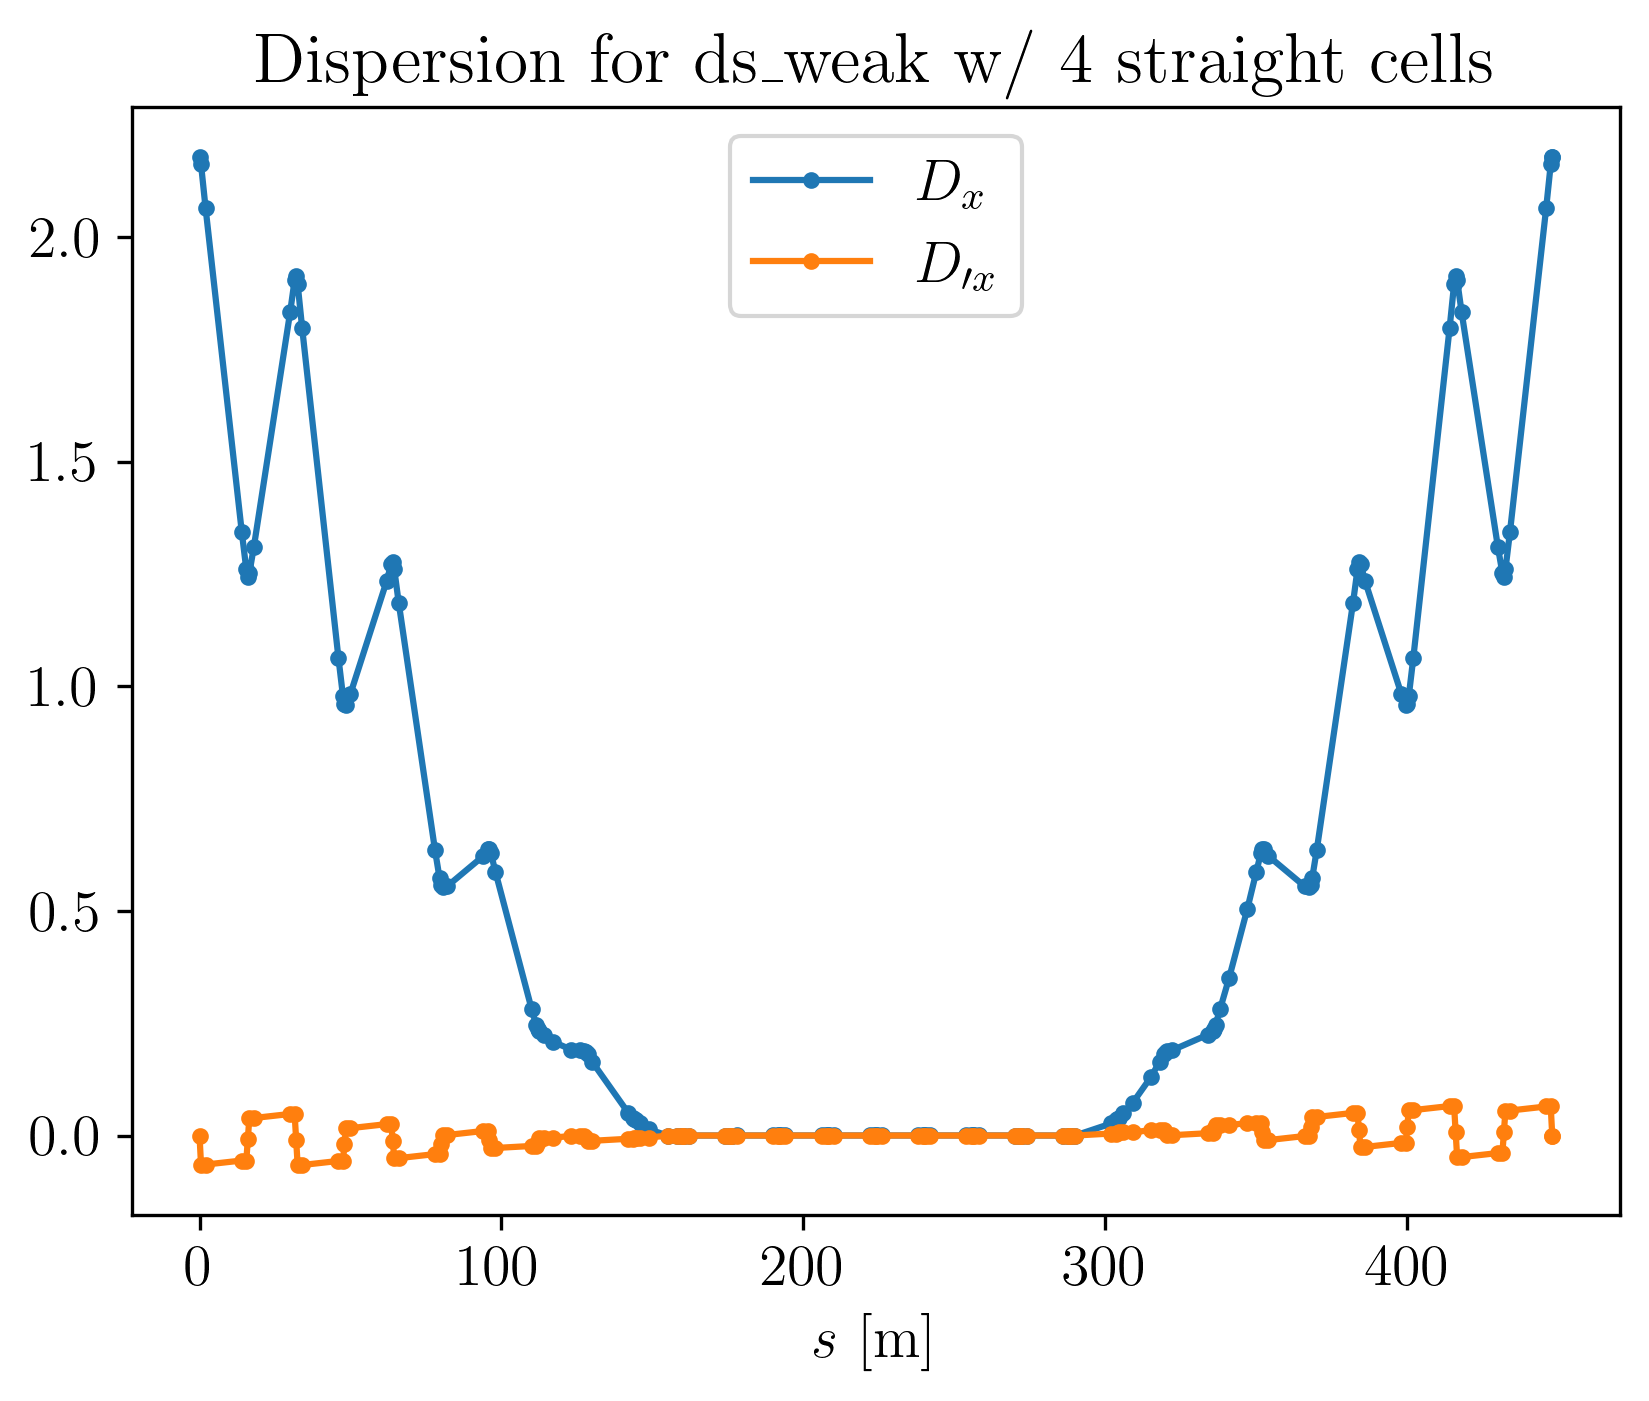

In [11]:
plt.title('Dispersion for ds_weak w/ 4 straight cells')
plt.plot(twiss7.s,twiss7.dx,'.-',label='$D_x$')
plt.plot(twiss7.s,twiss7.dpx,'.-',label='$D_{\prime x}$')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

The performace of ds_weak as a dispersion suppressor appears to be identical to the performance of ds_half. I believe this is because the bending centers (and phase advance) are the same.

### ds_comp:

In [14]:
madx8 = Madx(stdout=False)
madx8.input(f'''
    BEAM, particle=proton, energy=275.0;
    // Geometry
    L_drift  =  1.5;
    L_dipole = 12.0;
    L_quad   =  1.0;
    theta    =  0.036/4;
    
    L_half_arc_cell  = L_quad +       L_dipole + 2*L_drift;    // Regular arc half cell
    L_half_comp_cell = L_quad + (2/3)*L_dipole + 2*L_drift;    // Compact dispersion suppressor half cell
    
    // Strengths
    kd = 0.084;
    kf = 0.086;
    kdds = kd;
    kfds = kf;
    
    // Drifts
    D:        DRIFT, L =       L_drift;
    D_quart:  DRIFT, L = (1/4)*L_dipole;      // Quarter of the length of a dipole
    DIP_zero: DRIFT, L =       L_dipole;      // A full length, zero angle dipole, aka drift !!
    
    // Dipoles
    DIP_full: SBEND, L =       L_dipole, ANGLE =       theta;  // Nominal arc dipole
    DIP_half: SBEND, L = (1/2)*L_dipole, ANGLE = (1/2)*theta;  // Half length, half angle, full field
    DIP_weak: SBEND, L =       L_dipole, ANGLE = (1/2)*theta;  // Full length, half angle, half field
    DIP_comp:   SBEND, L = (2/3)*L_dipole, ANGLE = (2/3)*theta;  // 2/3  length, 2/3  angle, full field 
    
    // Quadrupoles
    QFH:   QUADRUPOLE, L= 0.5*L_quad, K1 :=  kf;    // Half an arc quad, F
    QDH:   QUADRUPOLE, L= 0.5*L_quad, K1 := -kd;    // Half an arc quad, D
    QFHds: QUADRUPOLE, L= 0.5*L_quad, K1 :=  kfds;  // Half a dispersion suppressor quad, F
    QDHds: QUADRUPOLE, L= 0.5*L_quad, K1 := -kdds;  // Half a dispersion suppressor quad, D
    
    // Beamlines
    interior_full: LINE=(D,          DIP_full,          D); // Interior with a full strength dipole
    interior_half: LINE=(D, D_quart, DIP_half, D_quart, D); // Interior with a half strength dipole
    interior_weak: LINE=(D,          DIP_weak,          D); // Alternate half strength interior
    interior_zero: LINE=(D,          DIP_zero,          D); // Interior with zero bend dipole
    interior_comp: LINE=(D,          DIP_comp,          D); // Compact interior
    
    cell_full: LINE=(QFH,   interior_full,   QDH,QDH,   interior_full, QFH);  // See figure
    cell_half: LINE=(QFH,   interior_half,   QDH,QDH,   interior_half, QFH);
    cell_weak: LINE=(QFH,   interior_weak,   QDH,QDH,   interior_half, QFH);
    cell_zero: LINE=(QFH,   interior_zero,   QDH,QDH,   interior_zero, QFH);
    cell_comp: LINE=(QFHds, interior_comp, QDHds,QDHds, interior_comp, QFHds);
    
    ds_none: LINE=(5*cell_full,              4*cell_zero,              5*cell_full);
    ds_half: LINE=(3*cell_full, 2*cell_half, 4*cell_zero, 2*cell_half, 3*cell_full);
    ds_weak: LINE=(3*cell_full, 2*cell_weak, 4*cell_zero, 2*cell_weak, 3*cell_full);
    ds_comp: LINE=(3*cell_full, 2*cell_comp, 4*cell_zero, 2*cell_comp, 3*cell_full);

    ! A) Find the quadrupole strengths that achieve the desired H & V phase advances per cell

    mux_goal = 0.25;
    muy_goal = 0.25;
    
    use, period = cell_full;
    match, sequence = cell_full;
           constraint, sequence = cell_full, range = #e, mux = mux_goal, muy = muy_goal;
           vary, name = kd, step = 0.000001;
           vary, name = kf, step = 0.000001;
           lmdif, calls = 5000, tolerance = 1.e-12;
    endmatch;
    print,  text = " ";
    print,  text = "AFTER MATCHING ARC CELL";
    printf, text = "Quad strengths in arc: kd,   kf   = %10.6f, %10.6f", value = kd, kf;
    
    use, period = cell_comp;
    match, sequence = cell_comp;
           constraint, sequence = cell_comp, range = #e, mux = mux_goal, muy = muy_goal;
           vary, name = kdds, step = 0.000001;
           vary, name = kfds, step = 0.000001;
           lmdif, calls = 5000, tolerance = 1.e-12;
    endmatch;
    print,  text = " ";
    print,  text = "AFTER MATCHING DISPERSION SUPPRESSOR CELL";
    printf, text = "Quad strengths in comp:  kdds, kfds = %10.6f, %10.6f", value = kdds, kfds;

    ! B) List and plot Twiss parameters for cell_comp.
    use, sequence = cell_comp;
    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
    
    ! C) List and plot Twiss parameters for a variety of dispersion supressor options

    !use, sequence = ds_none;  // goes directly from arc to straight, and back
    !use, sequence = ds_half;  // dispersion suppressor with 2 full length cells of half length, half angle dipoles
    !use, sequence = ds_weak;  // dispersion suppressor with 2 full length cells of full length, half angle dipoles
    use, sequence = ds_comp;  // dispersion suppressor with 2 compact cells of      3/4 length,  2/3 angle dipoles

    select, flag = twiss, column = name,s,betx,bety,alfx,alfy,dx,mux,muy;     // see all magnets
    set, format="-22s", "11.6f";
    twiss, save, file = disp_supp.twi;
    plot,   interpolate, haxis=s, hmax=500, vaxis1=betx,bety, vaxis2=dx, colour=100, file = disp_supp;

    stop;

''')
twiss8 = madx8.table.twiss

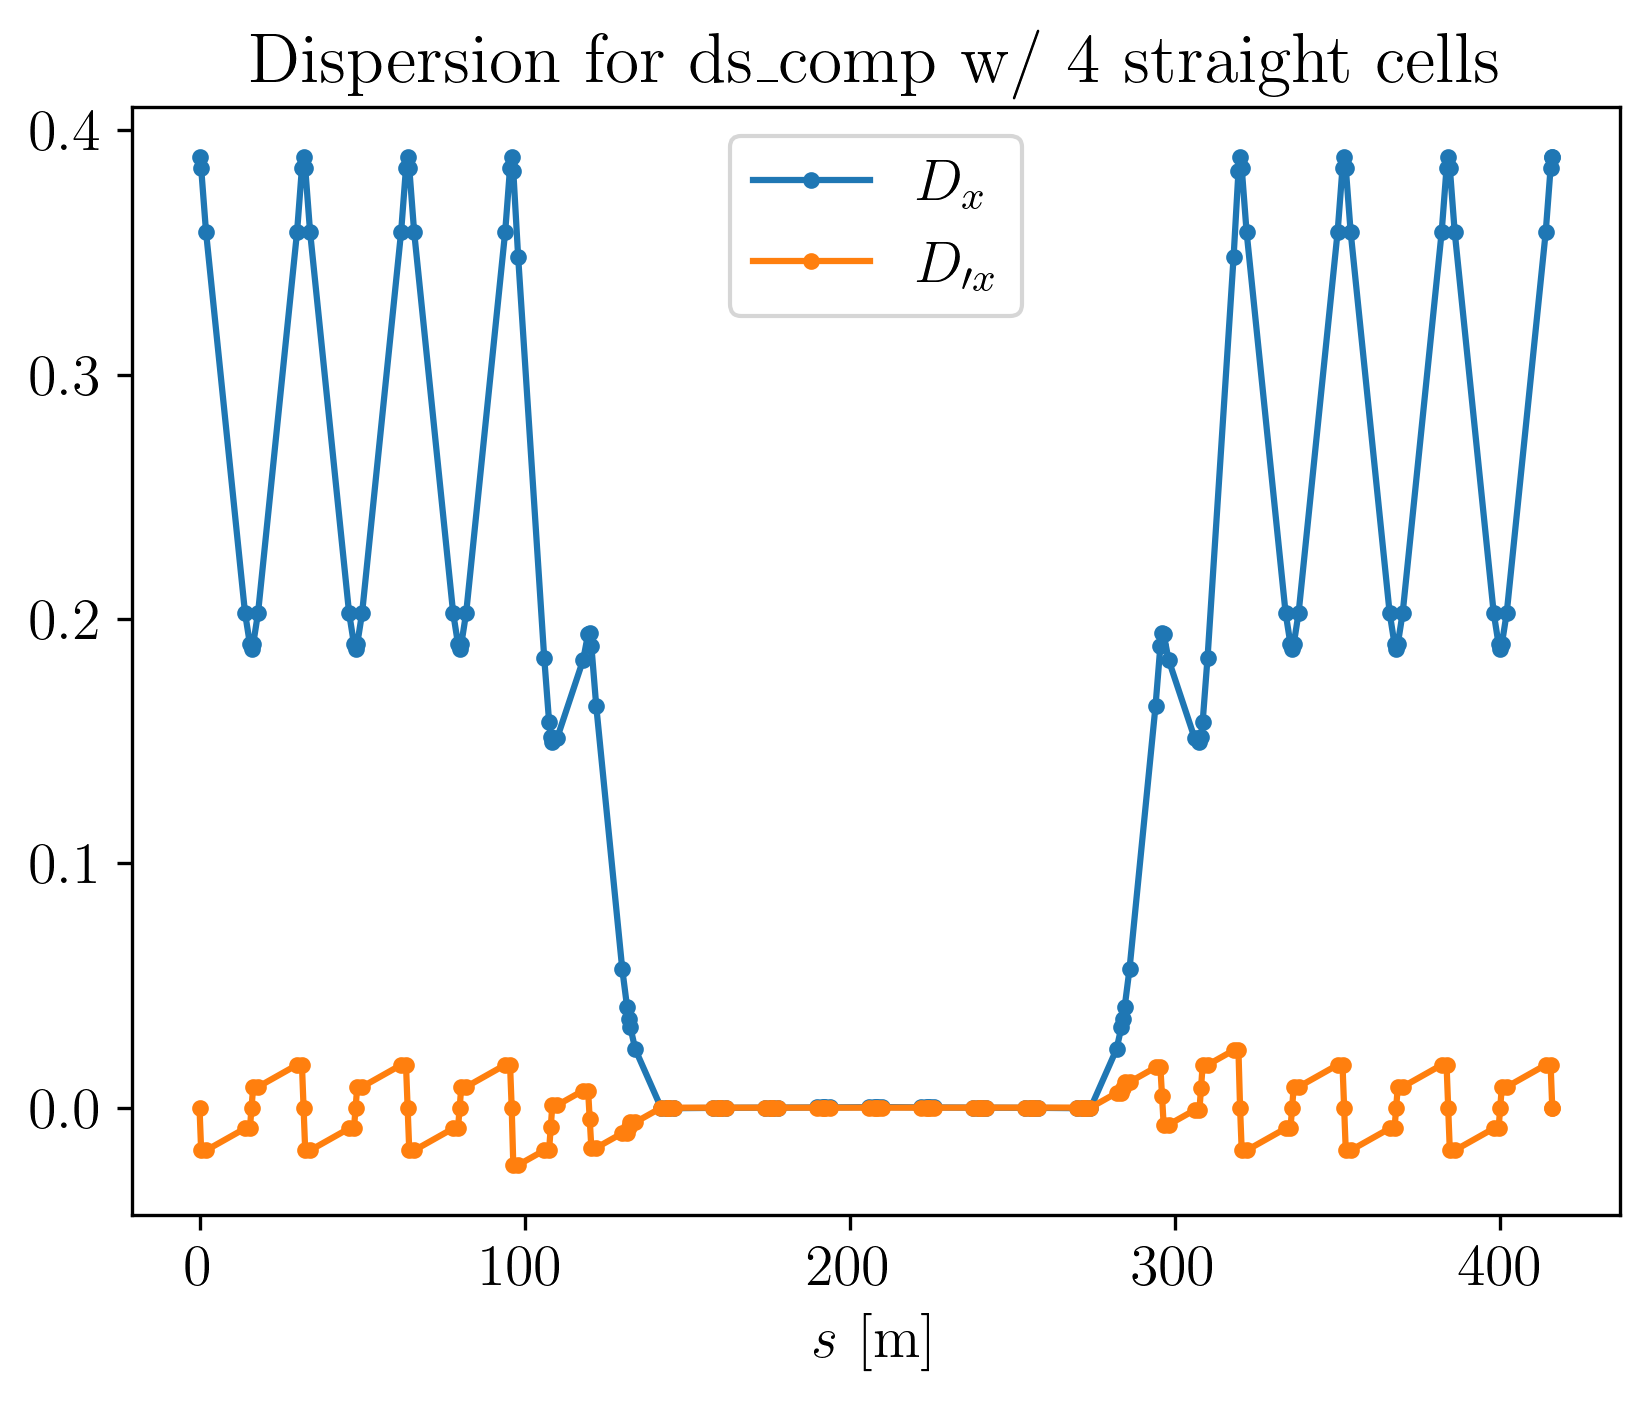

In [15]:
plt.title('Dispersion for ds_comp w/ 4 straight cells')
plt.plot(twiss8.s,twiss8.dx,'.-',label='$D_x$')
plt.plot(twiss8.s,twiss8.dpx,'.-',label='$D_{\prime x}$')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

Adjusting the phase advance to 0.25 yields similar performance to the ds_half and ds_weak cases!

Equation 4.18:
$$ \eta_{max} = L \theta \left(\frac{2+s}{2s^2} \right) \propto \frac{L^2}{\rho}$$
$$ \eta_{min} = L \theta \left(\frac{2-s}{2s^2} \right) \propto \frac{L^2}{\rho}$$
because
$$ L_{comp}\theta_{comp} = \frac{1}{2}L_{full}\theta_{full} $$

This condition makes a dispersion suppressor work well for ~180 degree phase advance per suppressor.

$\implies$ If the phase advance is ~60 degrees per arc cell, using 3 full DS cells with the cell_comp structure (2/3, 3/4) will yield ~180 degrees phase advance.